
UG RESEARCH IN MCMC METHODS FOR COSMOLOGICAL DATA ANALYSIS <br>
Preliminary Codes MCMC

1. Value of PI Using MC Integration

In [26]:
#IMPORTING ALL LIBRARIES
import numpy as np
import tabulate
import scipy as sp
import matplotlib.pyplot as plt

Value of pi using in-built function=  3.141592653589793
+--------------------+-------------------------+----------+
|   Number of trials |   Estimated Value of Pi |    Error |
+====================+=========================+==========+
|                100 |                 3.12    | 0.687316 |
+--------------------+-------------------------+----------+
|               1000 |                 3.124   | 0.559992 |
+--------------------+-------------------------+----------+
|              10000 |                 3.1576  | 0.50953  |
+--------------------+-------------------------+----------+
|             100000 |                 3.13724 | 0.138549 |
+--------------------+-------------------------+----------+


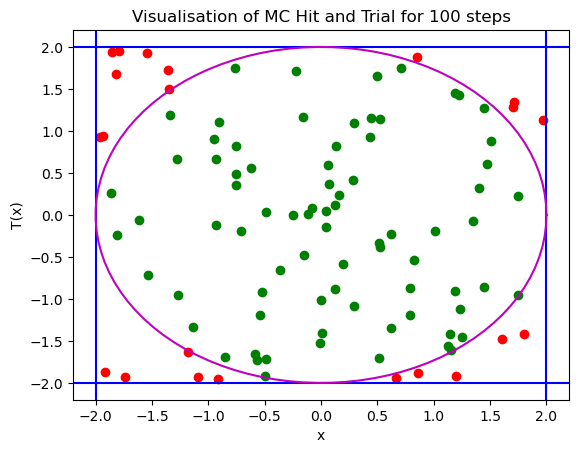

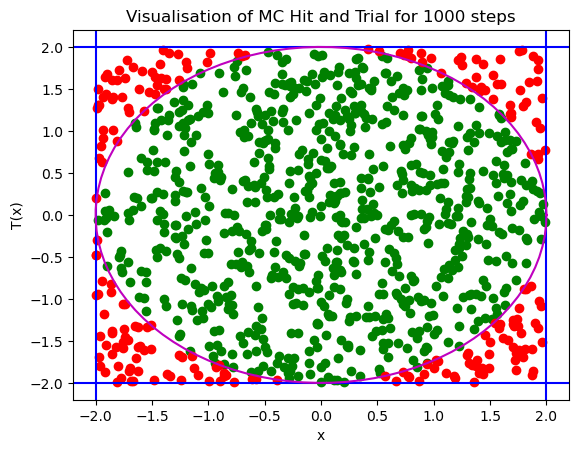

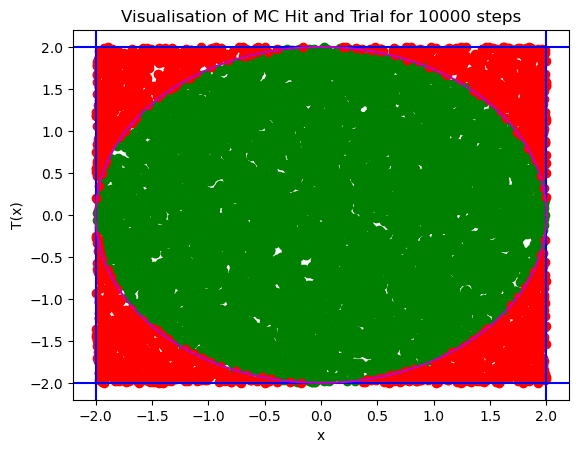

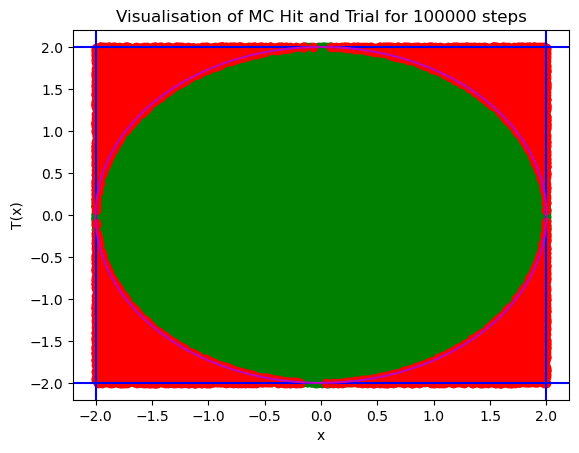

In [27]:
#VALUE OF PI USING AREA OF CIRCLE INSCRIBED IN SQUARE

#hit and miss method
r=2 #radius of circle
s=2*r #side of square
#assuming centre of circle at (0,0)
n_range=[100,1000,10000,100000] #number of trials/points visted
p_hit=[]

for j in n_range:
    x_plot_in=[]
    y_plot_in=[]
    x_plot_out=[]
    y_plot_out=[]
    cnt_in=0 #counter of hits
    for i in range(j):
         #generating random points inside square
         x= np.random.uniform(-r,r)
         y= np.random.uniform(-r,r)
         d = x*x + y*y #square distance of point from centre
         #for point to be on circle, x*x + y*y = r*r
         if d<=r*r:
             cnt_in += 1
             x_plot_in.append(x)
             y_plot_in.append(y)
         else:
             x_plot_out.append(x)
             y_plot_out.append(y)

    p_hit.append(cnt_in/j) #probability of hitting target area (MC approximation)

    #plotting the monte carlo method
    theta = np.linspace(0, 2 * np.pi, 100)
    x0 = r * np.cos(theta)
    y0 = r * np.sin(theta)

    plt.figure()
    plt.scatter(x_plot_in,y_plot_in,color='g',label='Hits')
    plt.scatter(x_plot_out,y_plot_out,color='r',label='Misses')
    plt.axvline(x=-r,ymin=-r,ymax=r,color='b')
    plt.axvline(x=r,ymin=-r,ymax=r,color='b')
    plt.axhline(y=-r,xmin=-r,xmax=r,color='b')
    plt.axhline(y=r,xmin=-r,xmax=r,color='b')
    plt.plot(x0,y0,'m')
    plt.title('Visualisation of MC Hit and Trial for '+str(j)+' steps')
    plt.xlabel('x')
    plt.ylabel('T(x)')


#equating to analytical value of p_hit = (area of target)/(total area) = pi*r*r/s*s = pi/4
p_hit=np.array(p_hit)
pi_val = 4 * p_hit

df=[]

print('Value of pi using in-built function= ', np.pi)
for k in range(len(n_range)):
    err= (np.abs(np.pi - pi_val[k])/np.pi) * 100
    df.append([n_range[k],pi_val[k],err])
print(tabulate.tabulate(df, headers=['Number of trials','Estimated Value of Pi','Error'],tablefmt='grid'))


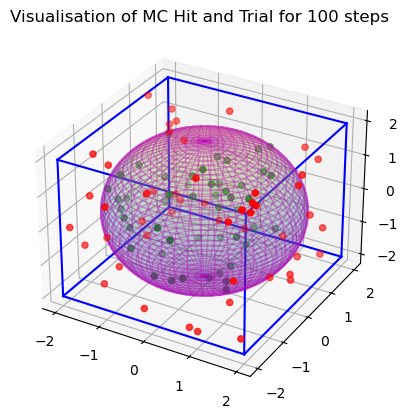

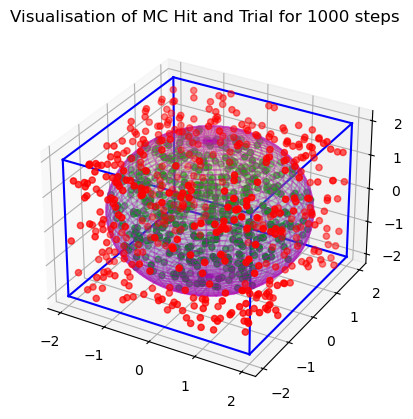

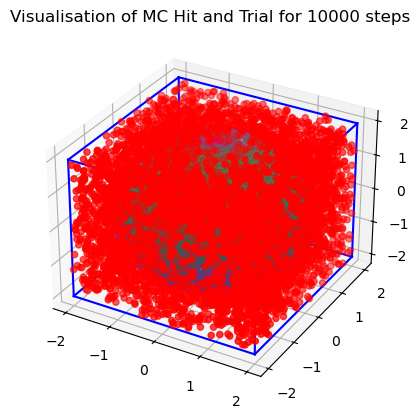

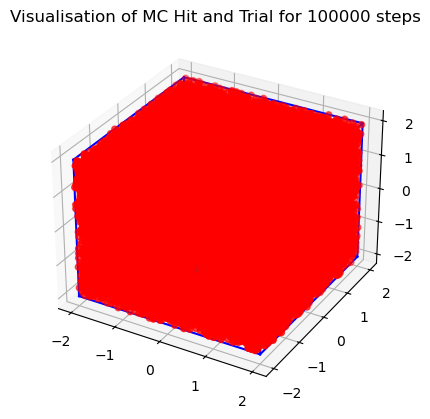

Value of pi using in-built function=  3.141592653589793
+--------------------+-------------------------+----------+
|   Number of trials |   Estimated Value of Pi |    Error |
+====================+=========================+==========+
|                100 |                 2.94    | 6.41689  |
+--------------------+-------------------------+----------+
|               1000 |                 3.174   | 1.03156  |
+--------------------+-------------------------+----------+
|              10000 |                 3.1572  | 0.496797 |
+--------------------+-------------------------+----------+
|             100000 |                 3.14964 | 0.256155 |
+--------------------+-------------------------+----------+


In [28]:
#VALE OF PI USING VOLUME OF SPHERE INSCRIBED IN A CUBE

#hit and miss method
r=2 #radius of circle
s=2*r #side of square
#assuming centre of circle at (0,0)
n_range=[100,1000,10000,100000] #number of trials/points visted
p_hit=[]

for j in n_range:
    cnt_in=0 #counter of hits
    x_plot_in=[]
    x_plot_out=[]
    y_plot_in=[]
    y_plot_out=[]
    z_plot_in=[]
    z_plot_out=[]
    for i in range(j):
         #generating random points inside square with centre at (0,0)
         x= np.random.uniform(-r,r)
         y= np.random.uniform(-r,r)
         z = np.random.uniform(-r,r)
         d = x*x + y*y + z*z #square distance of point from centre
         #for point to be on circle, x*x + y*y = r*r
         if d<=r*r and d>0:
             cnt_in += 1
             x_plot_in.append(x)
             y_plot_in.append(y)
             z_plot_in.append(z)
         else:
             x_plot_out.append(x)
             y_plot_out.append(y)
             z_plot_out.append(z)

    p_hit.append(cnt_in/j) #probability of hitting target area (MC approximation)

    #plotting the monte carlo method
    theta = np.linspace(0, 2*np.pi, 100)
    phi=np.linspace(0,np.pi,100)
    x0 = r * np.outer(np.cos(theta),np.sin(phi))
    y0 = r * np.outer(np.sin(theta),np.sin(phi))
    z0 = r * np.outer(np.ones(np.size(theta)), np.cos(phi))

    fig=plt.figure()
    ax=fig.add_subplot(projection='3d')
    ax.scatter(x_plot_in,y_plot_in,z_plot_in,color='g',label='Hits')
    ax.scatter(x_plot_out,y_plot_out,z_plot_out,color='r',label='Misses')
    x_range = np.linspace(-r,r,100)
    y_range = np.linspace(-r,r,100)
    z_range = np.linspace(-r,r,100)
    ax.plot(x_range,r,r,color='b')
    ax.plot(x_range,r,-r,color='b')
    ax.plot(x_range,-r,-r,color='b')
    ax.plot(x_range,-r,r,color='b')
    ax.plot(-r,y_range,r,color='b')
    ax.plot(-r,y_range,-r,color='b')
    ax.plot(r,y_range,-r,color='b')
    ax.plot(r,y_range,r,color='b')
    ax.plot(r,r,z_range,color='b')
    ax.plot(-r,r,z_range,color='b')
    ax.plot(r,-r,z_range,color='b')
    ax.plot(-r,-r,z_range,color='b')
    ax.plot_surface(x0,y0,z0, cmap='viridis', alpha=0.2, edgecolor='m')
    plt.title('Visualisation of MC Hit and Trial for '+str(j)+' steps')
    plt.show()


#equating to analytical value of p_hit = (volume of target)/(total volume) = ((4*pi*r^3)/3)/(8*r^3) = pi/6
p_hit=np.array(p_hit)
pi_val = (8*3/4) * p_hit

df=[]

print('Value of pi using in-built function= ', np.pi)
for k in range(len(n_range)):
    err= (np.abs(np.pi - pi_val[k])/np.pi) * 100
    df.append([n_range[k],pi_val[k],err])
print(tabulate.tabulate(df, headers=['Number of trials','Estimated Value of Pi','Error'],tablefmt='grid'))



2. Toy Model Using Metropolis-Hastings Algorithm

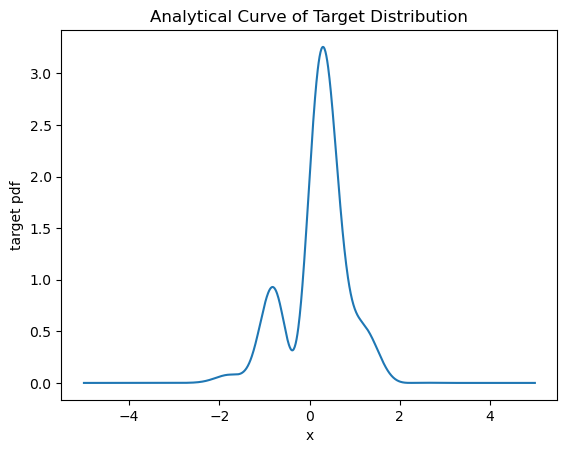

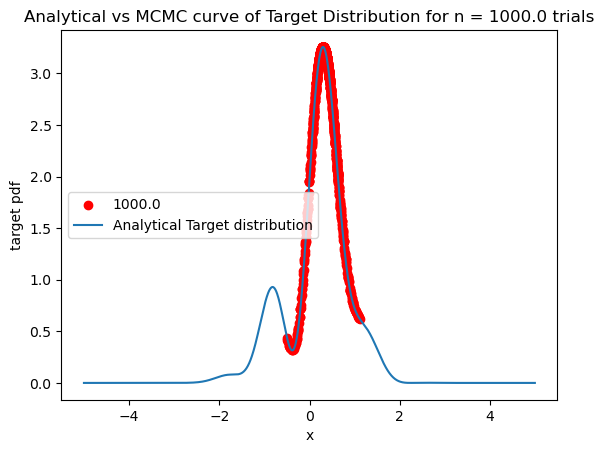

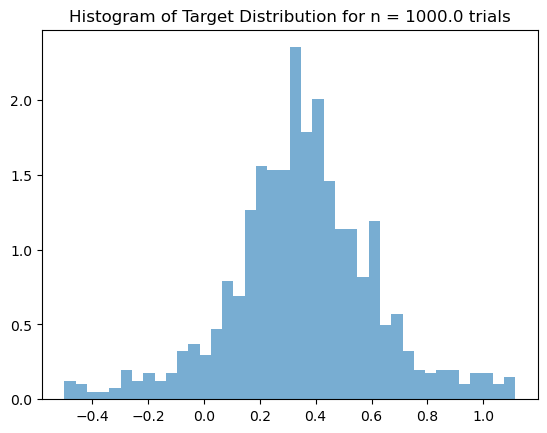

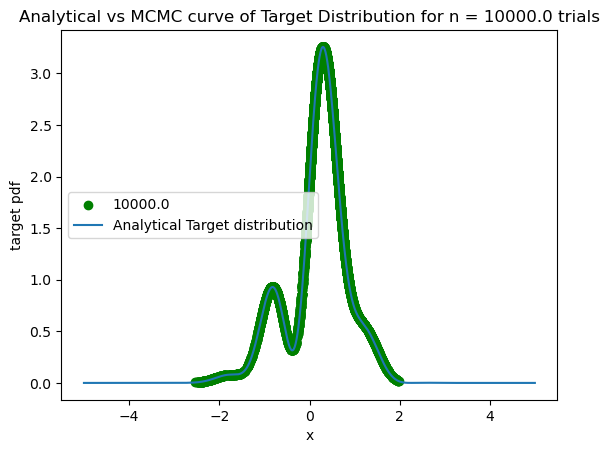

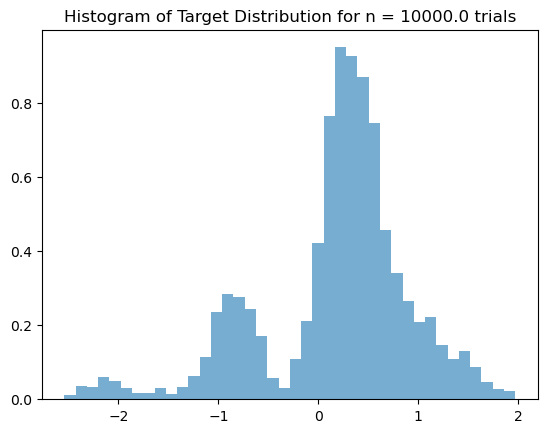

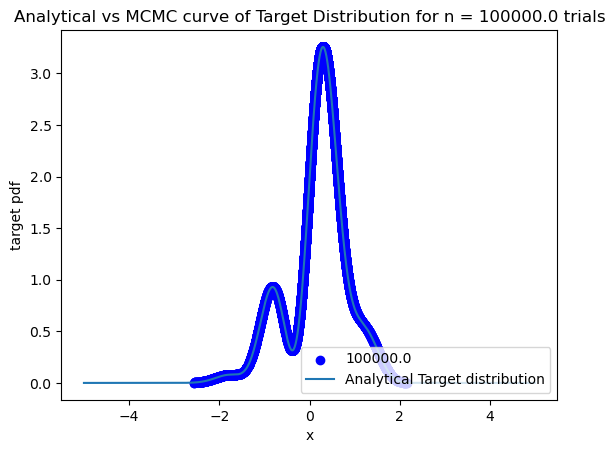

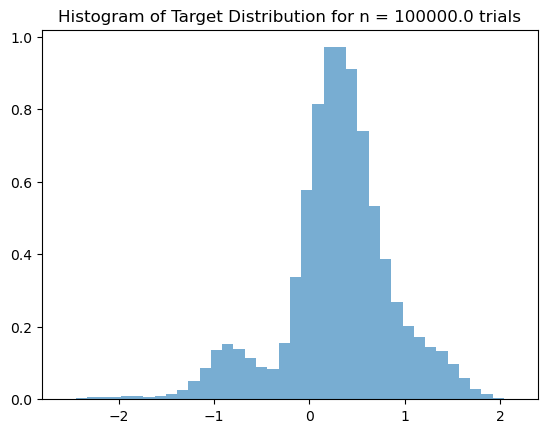

/opt/anaconda3/envs/koopman/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


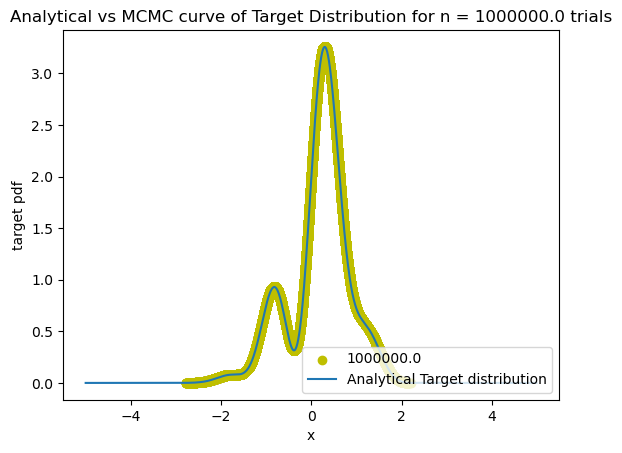

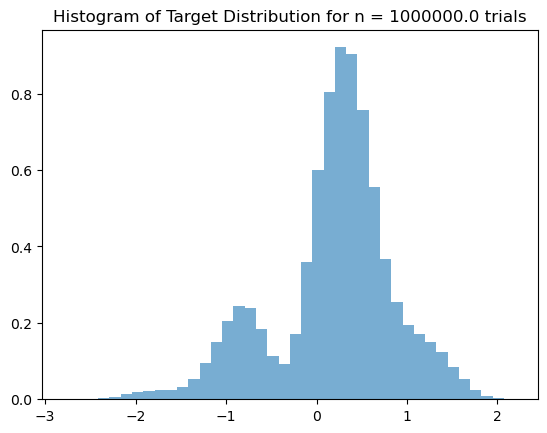

In [29]:
#metroplis-hastings toy model in 1D/ 1 variable
#sampling from some target distribution in 1 variable with target probabilities as described by the target func below

#TARGET DISTRIBUTION = e^(-x*x) * (2 + sin5x + sin2x)/integral (-inf-> inf)[e^(x*x) * (2 + 5sin5x + sin2x)]
def target_dist(x):
    t=np.exp(-x*x)*(2+np.sin(5*x)+np.sin(2*x))
    return t

#generating array of points and their target value
x=np.arange(-5,5,0.01)
target= target_dist(x)
#distribution visualisation
plt.figure()
plt.plot(x,target)
plt.title('Analytical Curve of Target Distribution')
plt.xlabel('x')
plt.ylabel('target pdf')
plt.show()

#generating markov chain
n_range= [1e3,1e4,1e5,1e6]
colors=['r','g','b','y']

for j in range(len(n_range)):
    n=n_range[j]
    accepted=[]
    #markov chains of sampled x and their target probabilities
    mc=np.zeros([int(n),2])
    cnt=0 #counter of accepted states
    x_in=0
    for i in range(int(n)):
        #generating new state
        x_new= x_in + np.random.uniform(-0.1,0.1)
        if x_new<=5 and x_new>=-5:
            a = target_dist(x_new)/target_dist(x_in) #=tij/tji
            #checking to see if its acceptable
            #if target_dist(x_new)>target_dist(x_in) or a>1,accept. if not, accept if some uniform random number < a.
            if a>1 or a>=np.random.uniform(0,1):
                cnt+=1
                accepted.append(cnt)
                x_in = x_new
        mc[i,0]=x_in
        mc[i,1]=target_dist(x_in)

    #generating a curve of the generated target distribution to plot
    plt.figure()
    plt.scatter(mc[:,0],mc[:,1],label=n,color=colors[j])
    plt.plot(x,target,label='Analytical Target distribution')
    plt.title('Analytical vs MCMC curve of Target Distribution for n = '+str(n)+' trials')
    plt.xlabel('x')
    plt.ylabel('target pdf')
    plt.legend()
    plt.show()

    #plotting histogram of markov states to see if analytical distribution is regenerated
    plt.figure()
    plt.hist(mc[:,0],bins=40,label='Accepted markov states',density=True,alpha=0.6)
    plt.title('Histogram of Target Distribution for n = '+str(n)+' trials')


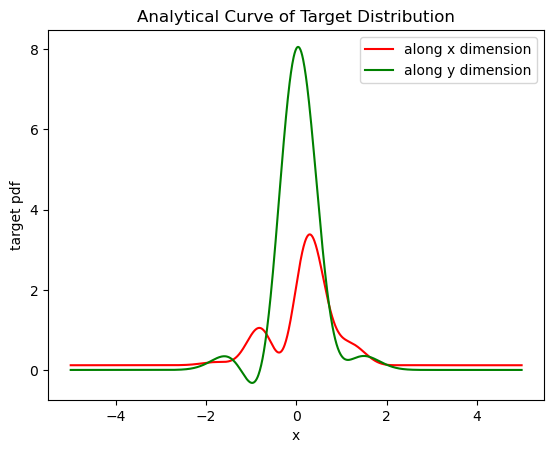

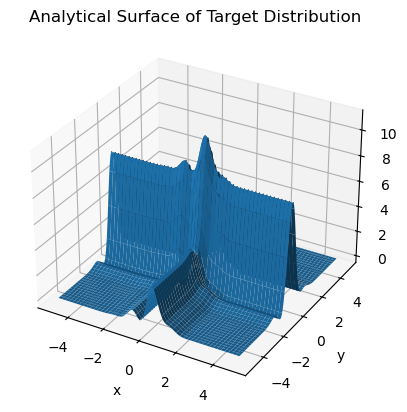

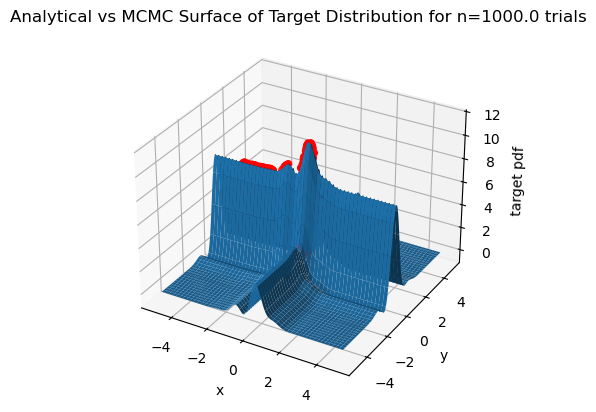

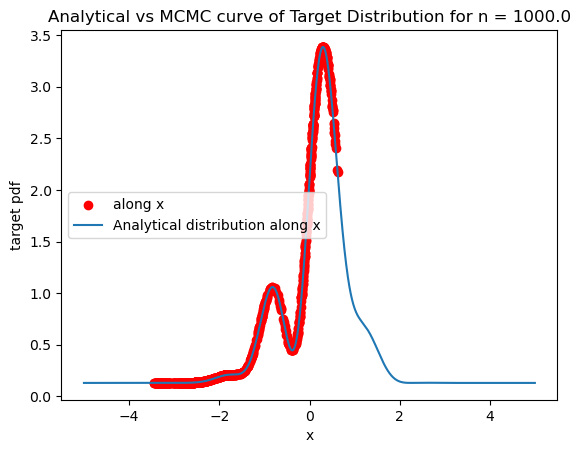

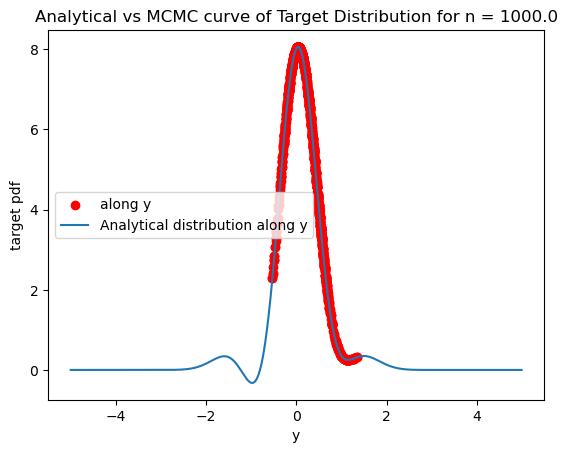

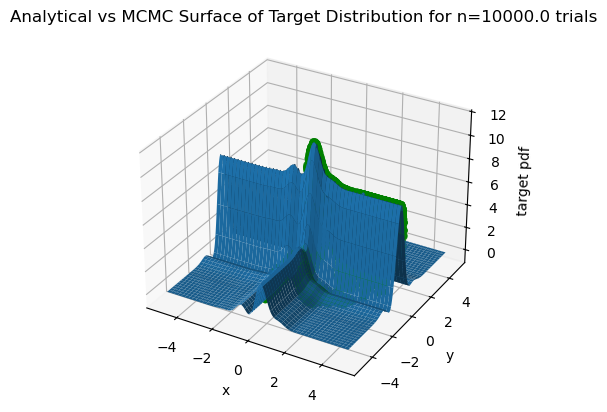

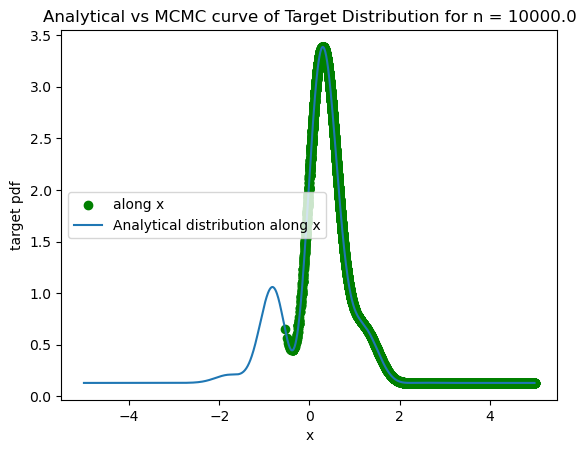

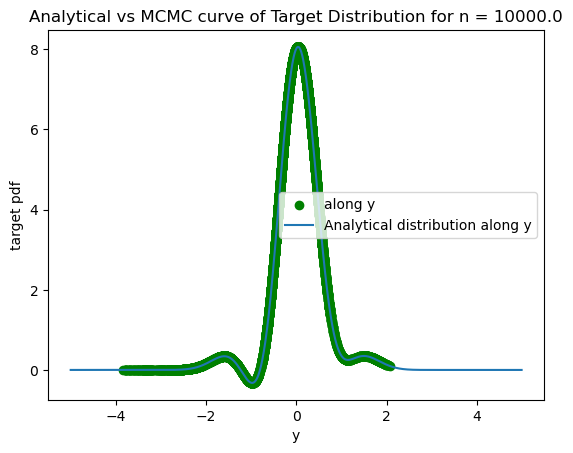

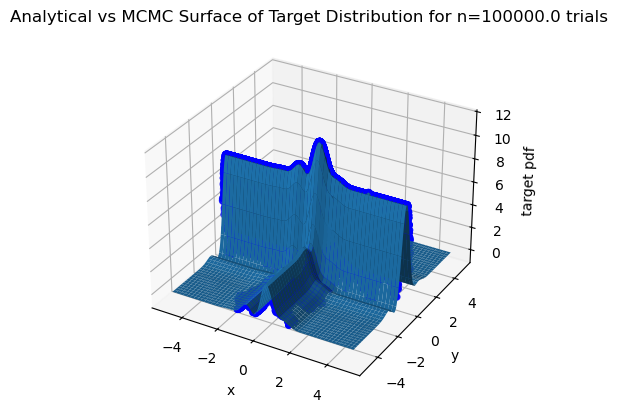

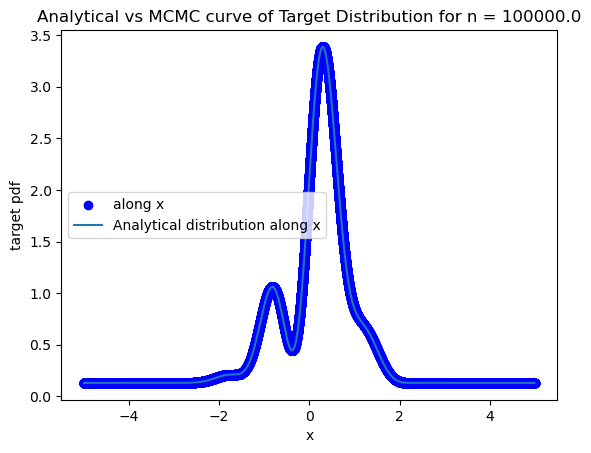

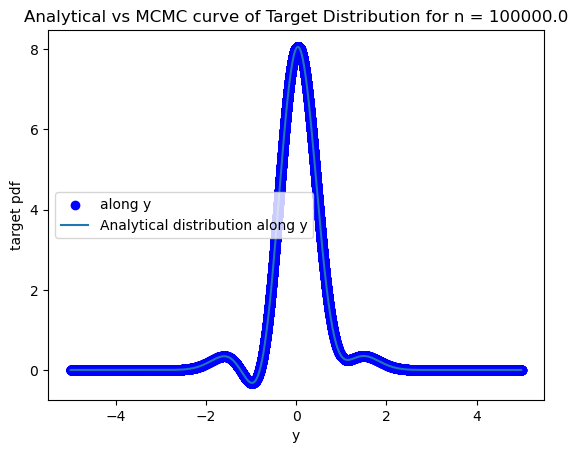

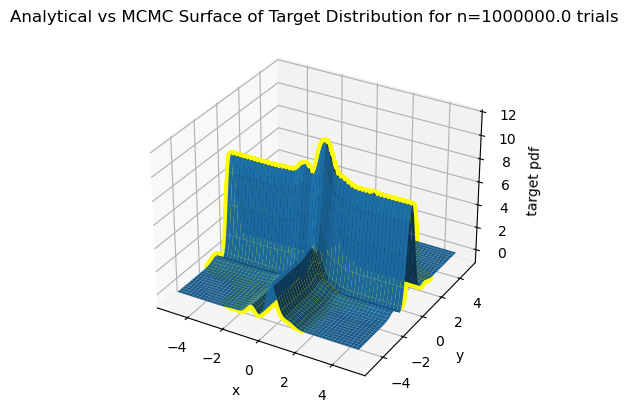

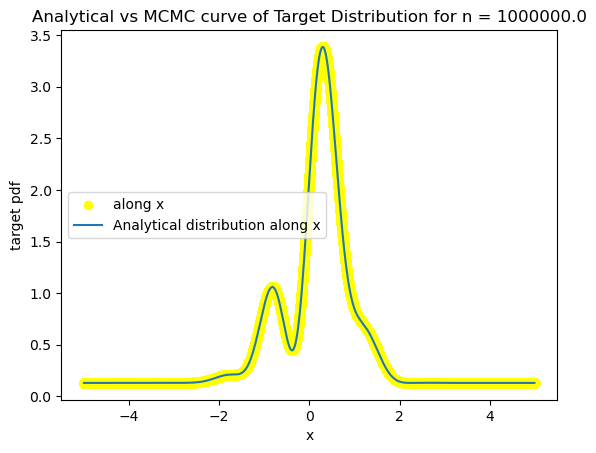

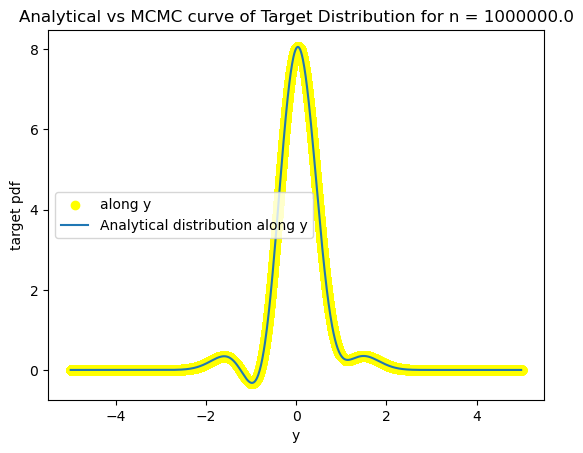

ValueError: ' trials' is not a valid value for loc; supported values are 'left', 'center', 'right'

<Figure size 640x480 with 0 Axes>

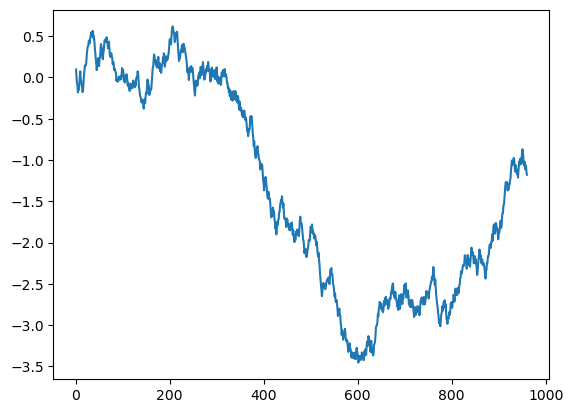

In [30]:
#metroplis-hastings toy model in 2D/ 2 variables
#sampling from some target distribution in 1 variable with target probabilities as described by the target func below

#TARGET DISTRIBUTION = e^(-x*x) * (2 + sin5x + sin2x) + e^(-y*y) * (4 + sin2y + 4cos3y)
def target_dist(x,y):
    t=np.exp(-x*x)*(2+np.sin(5*x)+np.sin(2*x)) + np.exp(-y*y)*(4+np.sin(2*y)+ 4*np.cos(3*y))
    return t

#generating array of points and their target value
x=np.arange(-5,5,0.01)
y=np.arange(-5,5,0.01)
X,Y=np.meshgrid(x,y)
T=target_dist(X,Y)
target_x= target_dist(x,2)
target_y= target_dist(2,y)
#distribution visualisation along one axis
plt.figure()
plt.plot(x,target_x,'r',label='along x dimension')
plt.plot(y,target_y,'g',label='along y dimension')
plt.title('Analytical Curve of Target Distribution')
plt.xlabel('x')
plt.ylabel('target pdf')
plt.legend()
plt.show()

#distribution visualisation in 3d
fig=plt.figure()
ax=fig.add_subplot(projection='3d')
ax.plot_surface(X,Y,T)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('target pdf')
ax.set_title('Analytical Surface of Target Distribution')
plt.show()

#generating markov chain
n_range= [1e3,1e4,1e5,1e6]
colors=['red','green','blue','yellow']

x_n=[]
y_n=[]
target_n=[]
accepted_n=[]

for j in range(len(n_range)):
    n=n_range[j]
    accepted=[]
    #markov chains of sampled x and their target probabilities
    mc=np.zeros([int(n),3])
    cnt=0 #counter of accepted states
    x_in=0
    y_in=0
    x_i=[]
    y_i=[]
    target_i=[]
    for i in range(int(n)):
        #generating new state
        x_new= x_in + np.random.uniform(-0.1,0.1)
        y_new= y_in + np.random.uniform(-0.1,0.1)
        if x_new<=5 and x_new>=-5 and y_new<=5 and y_new>=-5:
            a = target_dist(x_new,y_new)/target_dist(x_in,y_in) #=tij/tji
            # #checking to see if its acceptable
            #if target_dist(x_new)>target_dist(x_in) or a>1,accept. if not, accept if some uniform random number < a.
            if a>1 or a>=np.random.uniform(0,1):
                cnt+=1
                accepted.append(cnt)
                x_in = x_new
                y_in = y_new
                x_i.append(x_in)
                y_i.append(y_in)
                target_i.append(target_dist(x_in,y_in))
        mc[i,0]=x_in
        mc[i,1]=y_in
        mc[i,2]=target_dist(x_in,y_in)

    x_n.append(x_i)
    y_n.append(y_i)
    target_n.append(target_i)
    accepted_n.append(accepted)

    #generating a curve of the generated target distribution to plot in 3d
    fig=plt.figure()
    ax=fig.add_subplot(projection='3d')
    ax.scatter(mc[:,0],mc[:,1],mc[:,2],c=colors[j])
    ax.plot_surface(X,Y,T)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('target pdf')
    ax.set_title('Analytical vs MCMC Surface of Target Distribution for n='+str(n)+' trials')
    plt.show()

    #in 2d along one axis
    #x
    plt.figure()
    plt.scatter(mc[:,0],target_dist(mc[:,0],2),label='along x',color=colors[j])
    plt.plot(x,target_x,label='Analytical distribution along x')
    plt.title('Analytical vs MCMC curve of Target Distribution for n = '+str(n))
    plt.xlabel('x')
    plt.ylabel('target pdf')
    plt.legend()
    plt.show()

    #y
    plt.figure()
    plt.scatter(mc[:,1],target_dist(2,mc[:,1]),label='along y',color=colors[j])
    plt.plot(y,target_y,label='Analytical distribution along y')
    plt.title('Analytical vs MCMC curve of Target Distribution for n = '+str(n))
    plt.xlabel('y')
    plt.ylabel('target pdf')
    plt.legend()
    plt.show()

#plotting the markov chain accepted states
plt.figure()
for i in range(len(n_range)):
    num= accepted_n[i]
    X= x_n[i]
    plt.figure()
    plt.plot(num,X,label=n_range[i])
    plt.title('MH chain (walkers) for ', n_range[i], ' trials')
    plt.legend()
    plt.xlabel('#')
    plt.ylabel('x')
    plt.show()



3. Chi-Square Fitting of Given Data

----------QUANTITATIVE POINT MLE ESTIMATES OF PARAMETERS 1 FREE PARAM (FLAT UNIVERSE)----------
MLE estimate of Ω_M=  0.26110373593678315
MLE estimate of Ω_Λ = 1-Ω_M  =  0.7388962640632168
Value of  at MLE χ^2 =  2.764884266722513
1 sigma confidence interval limits= [ 0.302171458770972  , 0.44157963855622157 ]
2 sigma confidence interval limits= [ 0.24078619509806906  , 0.5076705477074476 ]
--------------------------------------------------------------------------------------


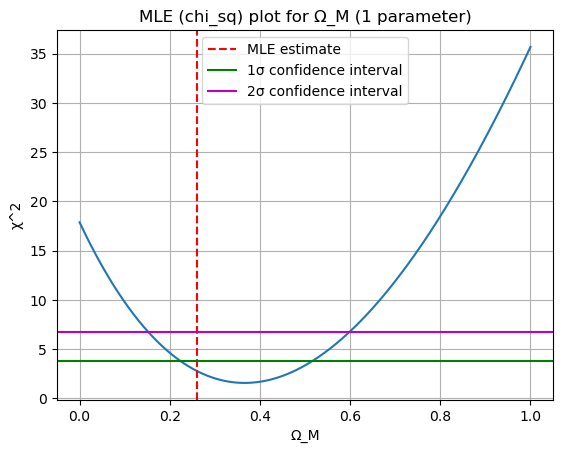

9958174
----------QUANTITATIVE POINT MLE ESTIMATES OF PARAMETERS 2 FREE PARAMS----------
MLE estimate of Ω_M=  0.39105110542744853
MLE estimate of Ω_Λ =  0.596762071757695
Value of  at MLE χ^2 =  1.5991874212961092
1 sigma confidence interval limits= [ [0.25084506 0.33765417]  , [0.53333357 0.84578379] ]
2 sigma confidence interval limits= [ [0.17407024 0.10678604]  , [0.66398517 0.96762589] ]
-------------------------------------------------------------------------


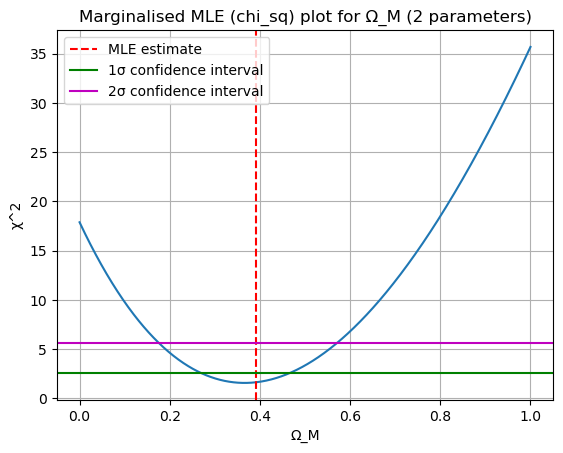

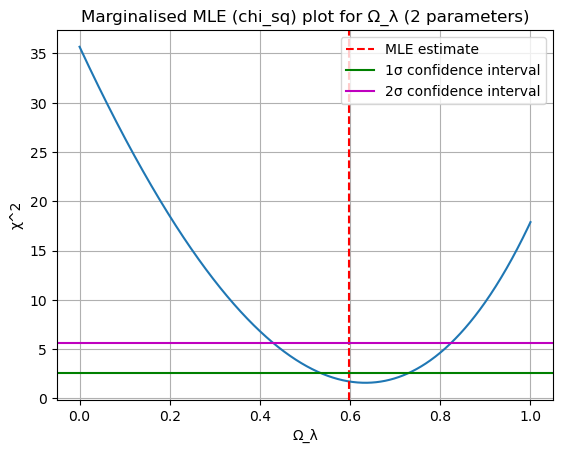

/var/folders/62/9gt108fd3rx02_2gg9kdt2lh0000gn/T/ipykernel_62470/3267382613.py:6: RuntimeWarning: invalid value encountered in sqrt
  H=H0*np.sqrt(omega_m*(1+z)**3 + omega_lam)


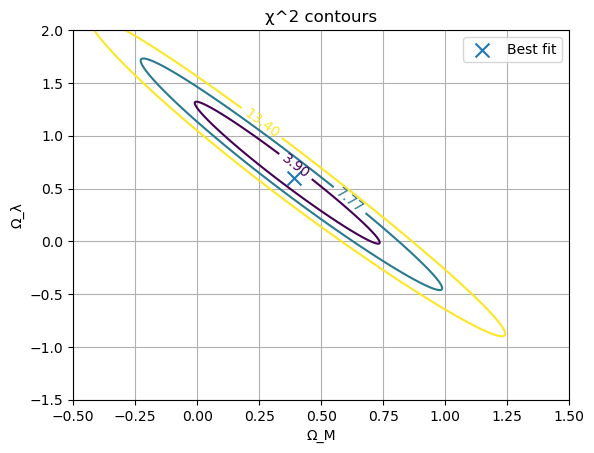

In [45]:
#chi-square fitting

#parent distribution function
def H_dist(z,omega_m,omega_lam):
    H0=67.8 #given
    H=H0*np.sqrt(omega_m*(1+z)**3 + omega_lam)
    return H

#chi-square
def chi_square(H_obs,H_model,sigma_H):
    chi2 = np.sum(((H_obs - H_model) / sigma_H)**2)
    return chi2

def likelihood(c2):
    return np.exp(-c2)

# Observational data
z = np.array([0.07, 0.09, 0.12, 0.17, 0.1791, 0.1993,0.20, 0.27, 0.28, 0.35, 0.3519, 0.3802, 0.40])
H_obs = np.array([69, 69, 68.6, 83, 75, 75, 72.9,77, 88.8, 82.7, 83, 83, 95])
sigma_H = np.array([19.6, 12, 26.2, 8, 4, 5, 29.6,14, 36.6, 8.4, 14, 13.5, 17])
H0 = 67.8

'''
--------------------------------------
1 FREE PARAMETER
--------------------------------------
'''
#assuming some earlier approx value of sigma_m as initial
omega_m = 0.3
omega_lam = 1-omega_m #flat universe model
H_model=H_dist(z,omega_m,omega_lam)
chi_sq= chi_square(H_obs,H_model,sigma_H)

#mcmc metropolis-hastings to minimize chi_square (likelihood as target dist)
steps=int(1e5)
chain_om=[]
chain_h=[]
chain_chi=[]
for i in range(steps):
    omega_m_new= omega_m + np.random.normal(0,0.25)
    if 0 <= omega_m_new <= 1: #checking if physically possible
        omega_lam_new= 1 - omega_m_new
        H_model_new= H_dist(z,omega_m_new,omega_lam_new)
        chi_sq_new= chi_square(H_model_new,H_obs,sigma_H)
        d_chi= chi_sq_new -chi_sq
        #acceptance probability
        if np.random.rand() < min(1,likelihood(d_chi)):
            omega_m = omega_m_new
            H_model = H_model_new
            chi_sq = chi_sq_new
        chain_om.append(omega_m)
        chain_h.append(H_model)
        chain_chi.append(chi_sq)

#final estimate after 1e4 steps taken as best-fit value of omega_m

#finding error/variance
#removing burn-in
burn_in=10000
#drawing samples after burn-in
samples=chain_om[burn_in:]
#confidence intervals
#1 sigma
lower_1sig,upper_1sig=np.percentile(samples,[16, 84])
# 2 sigma
lower_2sig, upper_2sig = np.percentile(samples,[2.5, 97.5])

print('----------QUANTITATIVE POINT MLE ESTIMATES OF PARAMETERS 1 FREE PARAM (FLAT UNIVERSE)----------')
print('MLE estimate of Ω_M= ',omega_m)
print('MLE estimate of Ω_Λ = 1-Ω_M  = ',1-omega_m)
print('Value of  at MLE χ^2 = ',chi_sq)
print('1 sigma confidence interval limits= [',lower_1sig,' ,',upper_1sig,']')
print('2 sigma confidence interval limits= [',lower_2sig,' ,',upper_2sig,']')
print('--------------------------------------------------------------------------------------')

#plotting fit
omega_m_range=np.array(np.linspace(0,1,1000))
chi_sq_range=[]
for om in omega_m_range:
    H_i=H_dist(z,om,1-om)
    chi_sq_range.append(chi_square(H_obs,H_i,sigma_H))
chi_sq_range=np.array(chi_sq_range)

plt.figure()
plt.plot(omega_m_range,chi_sq_range)
plt.axvline(omega_m,color='r',linestyle='--',label='MLE estimate')
plt.axhline(chain_chi[-1]+1,color='g',label='1σ confidence interval')
plt.axhline(chain_chi[-1]+4,color='m',label='2σ confidence interval')
plt.xlabel('Ω_M')
plt.ylabel('χ^2')
plt.title('MLE (chi_sq) plot for Ω_M (1 parameter)')
plt.legend()
plt.grid()
plt.show()

'''
--------------------------------------
2 FREE PARAMETERS
--------------------------------------
'''
#assuming some earlier approx value of sigma_m as initial
omega_m = 0.3
omega_lam = 0.7
params=np.array([omega_m,omega_lam])
H_model=H_dist(z,omega_m,omega_lam)
chi_sq= chi_square(H_obs,H_model,sigma_H)
#mcmc metropolis-hastings to minimize chi_square (likelihood as target dist)
steps=int(1e7)
chain_om=[]
chain_h=[]
chain_chi=[]
for i in range(steps):
    params_new = params + np.array([np.random.normal(0,0.05), np.random.normal(0,0.01)])
    if 0 <= params_new[0] <= 1 and 0 <= params_new[1] <= 1: #checking if physically possible
        H_model_new= H_dist(z,params_new[0],params_new[1])
        chi_sq_new= chi_square(H_model_new,H_obs,sigma_H)
        d_chi= chi_sq_new -chi_sq
        #acceptance probability
        if np.random.rand() < min(1,likelihood(d_chi)):
            params = params_new
            H_model = H_model_new
            chi_sq = chi_sq_new
        chain_om.append(params)
        chain_h.append(H_model)
        chain_chi.append(chi_sq)

#final estimate after 1e7 steps taken as best-fit value
print(len(chain_om))
#finding error/variance
#removing burn-in
burn_in=10000
#drawing samples after burn-in
samples=chain_om[burn_in:]
#confidence intervals
#1 sigma
lower_1sig,upper_1sig=np.percentile(samples,[16, 84],axis=0)
# 2 sigma
lower_2sig, upper_2sig = np.percentile(samples,[2.5, 97.5],axis=0)

print('----------QUANTITATIVE POINT MLE ESTIMATES OF PARAMETERS 2 FREE PARAMS----------')
print('MLE estimate of Ω_M= ',params[0])
print('MLE estimate of Ω_Λ = ',params[1])
print('Value of  at MLE χ^2 = ',chi_sq)
print('1 sigma confidence interval limits= [',lower_1sig,' ,',upper_1sig,']')
print('2 sigma confidence interval limits= [',lower_2sig,' ,',upper_2sig,']')
print('-------------------------------------------------------------------------')

#plotting marginalised chi_sq plots
#omega_m
omega_m_range=np.array(np.linspace(0,1,1000))
chi_sq_om=[]
for om in omega_m_range:
    #setting omega_lam=1-omega_m for marginal plots
    H_ij=H_dist(z,om,1-om)
    chi_sq_om.append(chi_square(H_obs,H_ij,sigma_H))
chi_sq_om=np.array(chi_sq_om)

plt.figure()
plt.plot(omega_m_range,chi_sq_om)
plt.axvline(params[0],color='r',linestyle='--',label='MLE estimate')
plt.axhline(chain_chi[-1]+1,color='g',label='1σ confidence interval')
plt.axhline(chain_chi[-1]+4,color='m',label='2σ confidence interval')
plt.xlabel('Ω_M')
plt.ylabel('χ^2')
plt.title('Marginalised MLE (chi_sq) plot for Ω_M (2 parameters)')
plt.legend()
plt.grid()
plt.show()

#omega_lam
omega_lam_range=np.array(np.linspace(0,1,1000))
chi_sq_ol=[]
for ol in omega_lam_range:
    #setting omega_m=1-omega_lam for marginal plots
    H_ij=H_dist(z,1-ol,ol)
    chi_sq_ol.append(chi_square(H_obs,H_ij,sigma_H))
chi_sq_ol=np.array(chi_sq_ol)

plt.figure()
plt.plot(omega_lam_range,chi_sq_ol)
plt.axvline(params[1],color='r',linestyle='--',label='MLE estimate')
plt.axhline(chain_chi[-1]+1,color='g',label='1σ confidence interval')
plt.axhline(chain_chi[-1]+4,color='m',label='2σ confidence interval')
plt.xlabel('Ω_λ')
plt.ylabel('χ^2')
plt.title('Marginalised MLE (chi_sq) plot for Ω_λ (2 parameters)')
plt.legend()
plt.grid()
plt.show()

#contour plots
omega_m_range=np.array(np.linspace(-0.5,1.5,1000))
omega_lam_range=np.array(np.linspace(-1.5,2,1000))
OM, OL = np.meshgrid(omega_m_range,omega_lam_range)
CHI2 = np.zeros(OM.shape)
for i in range(len(omega_lam_range)):
    for j in range(len(omega_m_range)):
        CHI2[i, j] = chi_square(H_obs,H_dist(z,OM[i, j],OL[i, j]),sigma_H)

plt.figure()
contours=plt.contour(OM,OL,CHI2, levels=[chi_sq + 2.30, chi_sq + 6.17,chi_sq + 11.8])
plt.clabel(contours, inline=True)
plt.scatter(params[0],params[1],marker='x',s=100,label='Best fit')
plt.xlabel('Ω_M')
plt.ylabel('Ω_λ')
plt.title('χ^2 contours')
plt.legend()
plt.grid()
plt.show()
